<a href="https://colab.research.google.com/github/codewithUswaFatima/urdu-ocr-codesaviours-si26-Uswa/blob/main/SI26_Week3_Uswa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python-headless pillow
import cv2
import numpy as np
from PIL import Image
import os
import glob
import matplotlib.pyplot as plt
print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip -o -q "/content/drive/MyDrive/Urdu_OCR_Project_Data (1) (1).zip" -d /content/

In [4]:
import glob

newspaper = glob.glob("/content/raw/newspaper/**/*.*", recursive=True)
synthetic = glob.glob("/content/raw/synthetic/**/*.*", recursive=True)
dataset = glob.glob("/content/raw/dataset/**/*.*", recursive=True)

print("Newspaper Images:", len(newspaper))
print("Synthetic Images:", len(synthetic))
print("Dataset Images:", len(dataset))
print("Total:", len(newspaper) + len(synthetic) + len(dataset))

Newspaper Images: 32
Synthetic Images: 20
Dataset Images: 50
Total: 102


In [5]:
os.makedirs("/content/processed", exist_ok=True)

In [6]:
import cv2
import os

def preprocess_image(image_path, save_path):

    # Load image
    img = cv2.imread(image_path)

    if img is None:
        print(f"Couldn't load {image_path}")
        return

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Resize image
    resized = cv2.resize(gray, (512, 128))

    # Remove noise
    denoised = cv2.fastNlMeansDenoising(resized, h=10)

    # Convert to black & white
    _, binary = cv2.threshold(denoised, 127, 255, cv2.THRESH_BINARY)

    # Save processed image
    cv2.imwrite(save_path, binary)

    return binary


# Create processed folder
os.makedirs("/content/processed", exist_ok=True)

print("Preprocessing function ready!")

Preprocessing function ready!


In [7]:
import os
from collections import Counter

extensions = Counter()

for root, dirs, files in os.walk("/content/raw"):
    for file in files:
        extensions[os.path.splitext(file)[1].lower()] += 1

print(extensions)

Counter({'.png': 50, '.jpeg': 32, '.jpg': 20})


In [8]:
import shutil
import os

if os.path.exists("/content/processed"):
    shutil.rmtree("/content/processed")

os.makedirs("/content/processed", exist_ok=True)

In [9]:
import glob
import os

all_images = glob.glob("/content/raw/**/*.png", recursive=True)
all_images += glob.glob("/content/raw/**/*.jpg", recursive=True)
all_images += glob.glob("/content/raw/**/*.jpeg", recursive=True)   # <-- Ye line add karo

print("Found", len(all_images), "images")

processed_count = 0

for img_path in all_images:

    filename = os.path.basename(img_path)

    save_path = "/content/processed/" + filename

    result = preprocess_image(img_path, save_path)

    if result is not None:
        processed_count += 1

print("Done! Processed", processed_count, "images")

Found 102 images
Done! Processed 102 images


In [10]:
import os

print("Processed Images:", len(os.listdir("/content/processed")))

Processed Images: 102


In [11]:
!apt-get install -y tesseract-ocr tesseract-ocr-urd
!pip install pytesseract


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  tesseract-ocr-urd
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 1,000 kB of archives.
After this operation, 1,413 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-urd all 1:4.00~git30-7274cfa-1.1 [1,000 kB]
Fetched 1,000 kB in 1s (844 kB/s)
Selecting previously unselected package tesseract-ocr-urd.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-urd_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-urd (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-urd (1:4.00~git30-7274cfa-1.1) ...


In [12]:
import pytesseract
from PIL  import Image
import glob

In [13]:
test_images = glob.glob("/content/processed/*.png")
test_images += glob.glob("/content/processed/*.jpg")
test_images += glob.glob("/content/processed/*.jpeg")

test_images = test_images[:5]

print("=====Tesseract OCR Results=====\n")

for img_path in test_images:
  img = Image.open(img_path)
  result = pytesseract.image_to_string(img, lang="urd")
  print("Image:",img_path)
  print("OCR Output:")
  print(result)
  print("-" * 50)

=====Tesseract OCR Results=====

Image: /content/processed/100.png
OCR Output:
راف وی اما

--------------------------------------------------
Image: /content/processed/1.png
OCR Output:
ءا ملا ےار ابی

--------------------------------------------------
Image: /content/processed/10006.png
OCR Output:
۷ ۸ں۷ىو00۷ 7

--------------------------------------------------
Image: /content/processed/10018.png
OCR Output:
زا لآ ول وی ادخ

--------------------------------------------------
Image: /content/processed/10017.png
OCR Output:

--------------------------------------------------


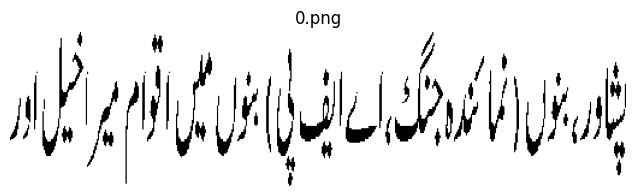

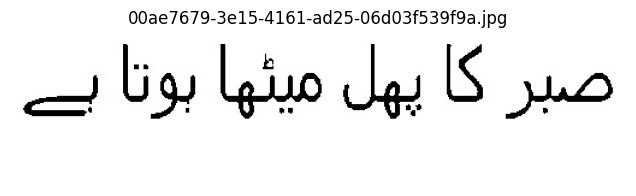

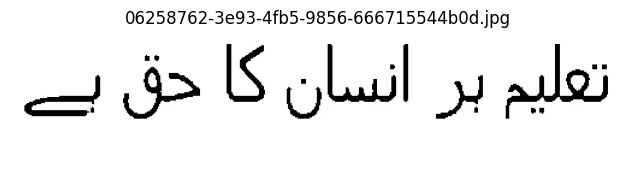

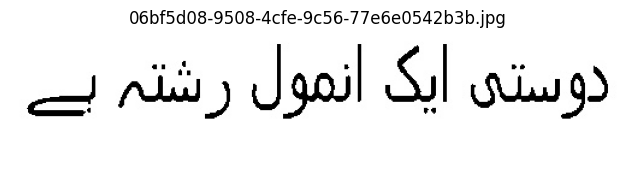

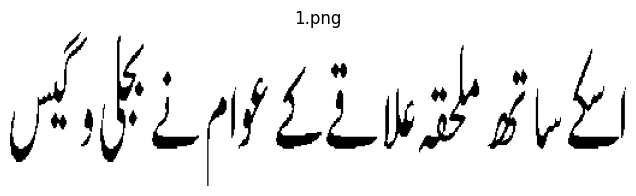

In [14]:
import matplotlib.pyplot as plt
from PIL import Image
import glob

test_images = glob.glob("/content/processed/*.png")
test_images += glob.glob("/content/processed/*.jpg")
test_images += glob.glob("/content/processed/*.jpeg")

test_images = sorted(test_images)[:5]

for img_path in test_images:
    img = Image.open(img_path)

    plt.figure(figsize=(10,2))
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(img_path.split("/")[-1])
    plt.show()

In [15]:
for img_path in test_images:
    img = Image.open(img_path)

    result = pytesseract.image_to_string(img, lang="urd")

    print("Image:", img_path.split("/")[-1])
    print(result)
    print("-"*50)

Image: 0.png
ای کی رر

--------------------------------------------------
Image: 00ae7679-3e15-4161-ad25-06d03f539f9a.jpg
صبر کا پھل میٹھا ہوتا ہے

--------------------------------------------------
Image: 06258762-3e93-4fb5-9856-666715544b0d.jpg
تعلیم بر انسان کا حق ہے

--------------------------------------------------
Image: 06bf5d08-9508-4cfe-9c56-77e6e0542b3b.jpg
دوستی ایک أنمول رشتہ ہے

--------------------------------------------------
Image: 1.png
ءا ملا ےار ابی

--------------------------------------------------


# **Gap Analysis**

### Per-Image Breakdown

**Image 1: `0.png`** (real/scanned image)
- Actual Urdu text: real-world scanned text (lower quality)
- Tesseract output: `ای کی رر`
- What went wrong: Completely gibberish — noise and uneven text in the real/scanned image caused characters to be misread entirely.

**Image 2: `00ae7679-3e15-4161-ad25-06d03f539f9a.jpg`** (synthetic/clean text)
- Actual Urdu text: صبر کا پھل میٹھا ہوتا ہے
- Tesseract output: صبر کا پھل میٹھا ہوتا ہے
- What went wrong: Nothing — this clean, synthetic (typed) image was recognized correctly.

**Image 3: `06258762-3e93-4fb5-9856-666715544b0d.jpg`** (synthetic/clean text)
- Actual Urdu text: تعلیم پر انسان کا حق ہے
- Tesseract output: تعلیم بر انسان کا حق ہے
- What went wrong: One character error — "پر" was misread as "بر" (پ and ب are visually similar, differing only by dot placement).

**Image 4: `06bf5d08-9508-4cfe-9c56-77e6e0542b3b.jpg`** (synthetic/clean text)
- Actual Urdu text: دوستی ایک انمول رشتہ ہے
- Tesseract output: دوستی ایک أنمول رشتہ ہے
- What went wrong: An extra hamza character was inserted — "انمول" became "أنمول".

**Image 5: `1.png`** (real/scanned image)
- Actual Urdu text: real-world scanned text
- Tesseract output: `ءا ملا ےار ابی`
- What went wrong: Completely gibberish — spacing and character joining were not handled correctly, since Urdu is a cursive script and this was a noisy real-world image.

### Key Pattern Observed
Tesseract performed **very well on clean, synthetic (typed) text**, but performed **very poorly on real-world scanned/photographed images** — showing that noise, lighting, and natural distortion are the biggest challenges, not just the script itself.

### Conclusion

**Tesseract fails on Urdu because it struggles with cursive, joined characters (visually similar letters like پ and ب get confused), and performs drastically worse on real-world scanned or photographed images compared to clean synthetic text.** This shows Tesseract only works reliably in ideal conditions and cannot handle the noise, distortion, and natural variation present in real Urdu documents — which is exactly why a custom-trained OCR model is needed for this project.


In [3]:

import os
import csv
import glob
import shutil
import zipfile
import pandas as pd

RAW_DIR = "/content/raw"
LABELS_CSV = "/content/labels (2).csv"

In [17]:
# ---------------------------------------------------------------
# STEP 1 — Extract all 4 zips into their own raw/ subfolders
# ---------------------------------------------------------------
zips_to_extract = {
    "ravi_raw":       "/content/drive/MyDrive/RAVI Synthetic Urdu Text Image Dataset for OCR.zip",
    "handwritten":    "/content/drive/MyDrive/Hand_written_images.zip",
    "jang":           "/content/drive/MyDrive/Jang_newspaper_images.zip",
    "printed":        "/content/drive/MyDrive/Printed_Text_images.zip",
}

for folder_name, zip_path in zips_to_extract.items():
    out_dir = os.path.join(RAW_DIR, folder_name)
    os.makedirs(out_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(out_dir)
    print(f"Extracted {zip_path} -> {out_dir}")

# NOTE: RAVI zip has a zip-inside-a-zip. If extraction above only gives you
# a single .zip file inside ravi_raw, run this too:
inner_zip = glob.glob(os.path.join(RAW_DIR, "ravi_raw", "**", "*.zip"), recursive=True)
if inner_zip:
    with zipfile.ZipFile(inner_zip[0], "r") as zf:
        zf.extractall(os.path.join(RAW_DIR, "ravi_raw"))
    print("Extracted nested RAVI zip too.")


Extracted /content/drive/MyDrive/RAVI Synthetic Urdu Text Image Dataset for OCR.zip -> /content/raw/ravi_raw
Extracted /content/drive/MyDrive/Hand_written_images.zip -> /content/raw/handwritten
Extracted /content/drive/MyDrive/Jang_newspaper_images.zip -> /content/raw/jang
Extracted /content/drive/MyDrive/Printed_Text_images.zip -> /content/raw/printed
Extracted nested RAVI zip too.


In [18]:

# ---------------------------------------------------------------

def decode_ravi_filename(filename):
    return os.path.splitext(filename)[0]   # filename already IS the Urdu word

ravi_dataset_root = os.path.join(RAW_DIR, "ravi_raw", "RAVI_dataset")

os.makedirs(os.path.join(RAW_DIR, "ravi"), exist_ok=True)

ravi_rows = []
letter_folders = sorted(
    d for d in os.listdir(ravi_dataset_root)
    if os.path.isdir(os.path.join(ravi_dataset_root, d))
)
for folder in letter_folders:
    files = sorted(glob.glob(os.path.join(ravi_dataset_root, folder, "*.png")))[:2]
    for fpath in files:
        fname = os.path.basename(fpath)
        dest = os.path.join(RAW_DIR, "ravi", fname)
        shutil.copy(fpath, dest)
        ravi_rows.append({
            "image": f"raw/ravi/{fname}",
            "text": decode_ravi_filename(fname),
        })

print(f"RAVI images added: {len(ravi_rows)}")

RAVI images added: 74


In [19]:
# ---------------------------------------------------------------
# STEP 3 — Handwritten / Jang / Printed: these have NO ground-truth
# text anywhere, so we add them with a placeholder. YOU must open
# each image and type the correct Urdu text before Week 4 training.
# ---------------------------------------------------------------
def add_placeholder_rows(folder_name, csv_prefix):
    rows = []
    folder_path = os.path.join(RAW_DIR, folder_name)
    image_files = []
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        image_files += glob.glob(os.path.join(folder_path, "**", ext), recursive=True)

    for fpath in sorted(image_files):
        fname = os.path.basename(fpath)
        rel_path = os.path.relpath(fpath, RAW_DIR)
        rows.append({
            "image": f"raw/{rel_path}",
            "text": "WRITE_THE_URDU_TEXT_HERE",
        })
    print(f"{folder_name}: {len(rows)} images found")
    return rows

handwritten_rows = add_placeholder_rows("handwritten", "handwritten")
jang_rows = add_placeholder_rows("jang", "jang")
printed_rows = add_placeholder_rows("printed", "printed")

handwritten: 10 images found
jang: 10 images found
printed: 10 images found


In [20]:
# ---------------------------------------------------------------
# STEP 4 — Append everything to the existing labels.csv
# ---------------------------------------------------------------
existing = pd.read_csv(LABELS_CSV)
print("Existing rows before update:", len(existing))

new_rows = ravi_rows + handwritten_rows + jang_rows + printed_rows
new_df = pd.DataFrame(new_rows)

combined = pd.concat([existing, new_df], ignore_index=True)
combined.to_csv(LABELS_CSV, index=False, encoding="utf-8")

print("Total rows after update:", len(combined))
print("Rows still needing manual text (placeholder):",
      (combined["text"] == "WRITE_THE_URDU_TEXT_HERE").sum())

Existing rows before update: 99
Total rows after update: 203
Rows still needing manual text (placeholder): 30


In [21]:
# ---------------------------------------------------------------
# FIX: normalize image paths in labels.csv
# Some Week 1 rows were saved with a wrong 'data/raw/...' prefix and
# missing nested subfolders (e.g. newspaper/screenshots, synthetic/synthetic).
# This rebuilds every path by matching filenames against what's actually
# on disk, so the Dataset class can open every image correctly.
# ---------------------------------------------------------------
import os, glob, pandas as pd

df = pd.read_csv(LABELS_CSV)

all_files = glob.glob(os.path.join(RAW_DIR, "**", "*.*"), recursive=True)
lookup = {os.path.basename(f): os.path.relpath(f, "/content") for f in all_files}

fixed, missing, new_paths = 0, [], []
for p in df["image"]:
    full = p if os.path.isabs(p) else os.path.join("/content", p)
    if os.path.exists(full):
        new_paths.append(p)
    else:
        bn = os.path.basename(p)
        if bn in lookup:
            new_paths.append(lookup[bn])
            fixed += 1
        else:
            new_paths.append(p)
            missing.append(p)

df["image"] = new_paths
df.to_csv(LABELS_CSV, index=False, encoding="utf-8")

print("Total rows:", len(df))
print("Auto-fixed paths:", fixed)
print("Still missing (need your attention):", len(missing))
if missing:
    print("Examples:", missing[:10])


Total rows: 203
Auto-fixed paths: 99
Still missing (need your attention): 0


## Manual Labeling — Fill in the 30 Missing Urdu Texts

`handwritten`, `jang`, and `printed` images have no ground-truth text anywhere (unlike RAVI, where the filename already contains the word). You need to **look at each image and type the correct Urdu text** you see.

**Steps:**
1. Run the next cell — it displays every placeholder image with its filename.
2. Read the Urdu text in each image.
3. Fill in the `manual_labels` dictionary in the cell after that (filename -> correct text).
4. Run the update cell — it writes your text into `labels.csv`, replacing the placeholder.

Tip: if typing Urdu directly in Colab is awkward, you can instead download `labels (2).csv`, open it in Google Sheets (handles Urdu/RTL text well), fill the `text` column for rows that still say `WRITE_THE_URDU_TEXT_HERE`, then re-upload and overwrite the file.

30 images still need manual text.



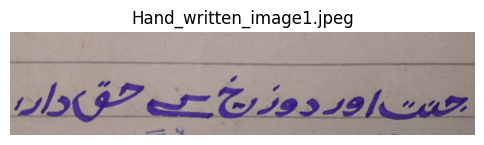

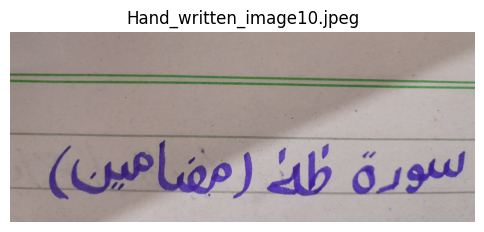

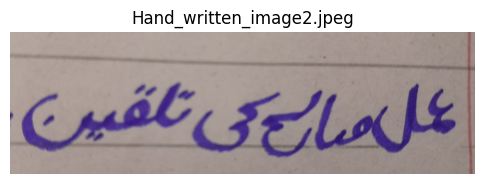

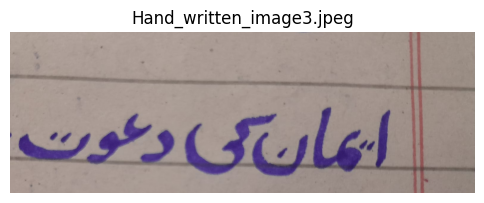

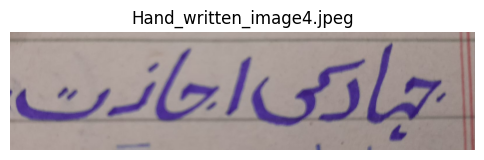

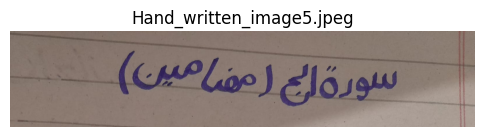

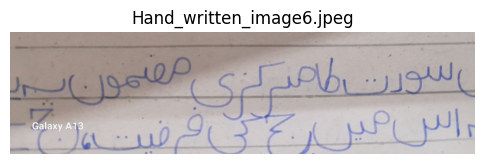

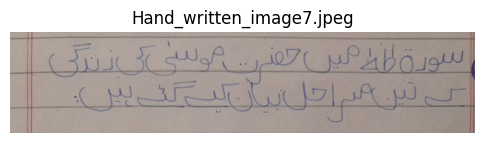

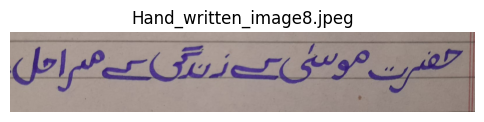

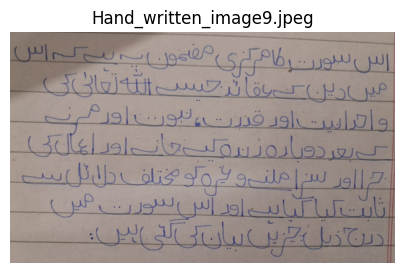

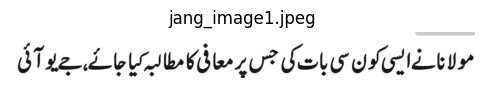

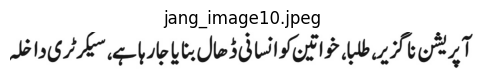

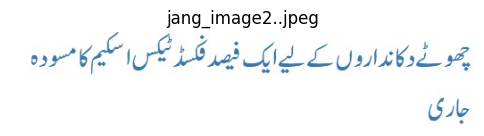

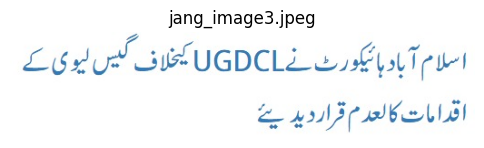

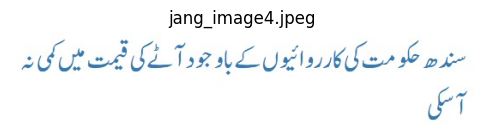

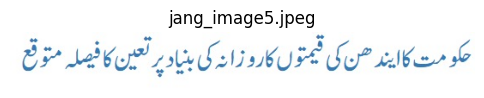

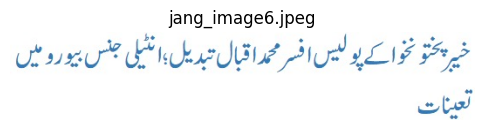

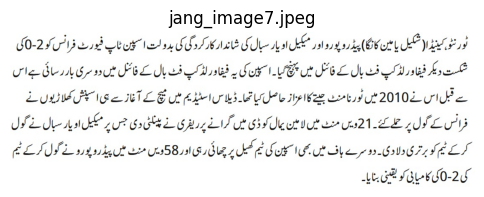

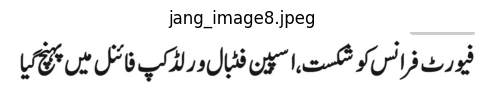

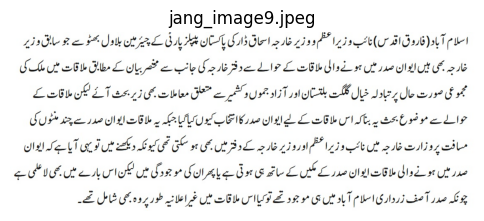

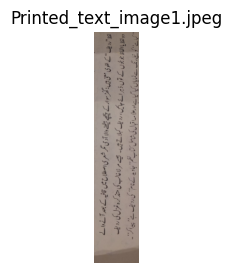

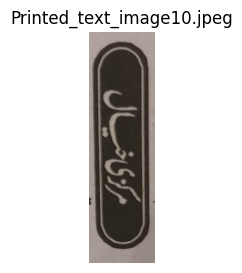

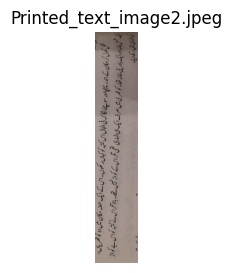

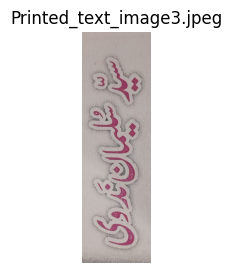

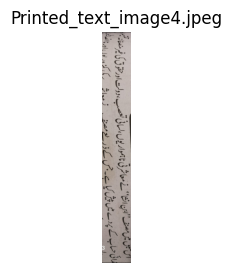

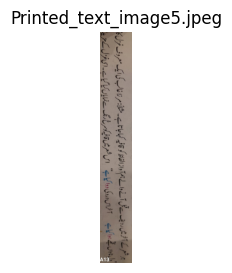

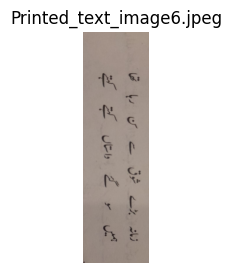

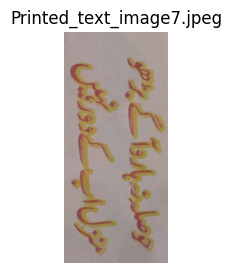

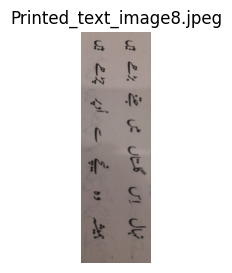

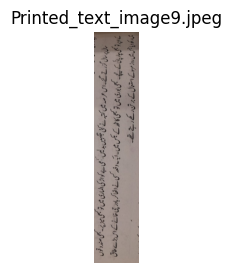

In [22]:
import matplotlib.pyplot as plt
from PIL import Image

df = pd.read_csv(LABELS_CSV)
placeholder_rows = df[df["text"] == "WRITE_THE_URDU_TEXT_HERE"]

print(f"{len(placeholder_rows)} images still need manual text.\n")

for _, row in placeholder_rows.iterrows():
    path = row["image"]
    full = path if os.path.isabs(path) else os.path.join("/content", path)
    img = Image.open(full)
    plt.figure(figsize=(6, 3))
    plt.imshow(img)
    plt.axis("off")
    plt.title(os.path.basename(path))
    plt.show()


In [23]:
manual_labels = {

    "jang_image1.jpeg": "مولانا نے ایسی کون سی بات کی جس پر معافی کا مطالبہ کیا جائے، جیو آئی",
    "jang_image2..jpeg": "چھوٹے دکانداروں کے لیے ایک فیصد فکسڈ ٹیکس اسکیم کا مسودہ جاری",
    "jang_image3.jpeg": "اسلام آباد ہائیکورٹ نے UGDCL کیخلاف گیس لیوی کے اقدامات کالعدم قرار دیئے",
    "jang_image4.jpeg": "سندھ حکومت کی کارروائیوں کے باوجود آٹے کی قیمت میں کمی نہ آسکی",
    "jang_image5.jpeg": "حکومت کا ایندھن کی قیمتوں کا روزانہ بنیاد پر تعین کا فیصلہ متوقع",
    "jang_image6.jpeg": "خیبر پختونخوا کے پولیس افسر محمد اقبال تبدیل؛ انٹیلی جنس بیورو میں تعیناتی",
    "jang_image7.jpeg": "ٹورنٹو، کینیڈا(شکیل یامین کانگا) پیڈرو پورو اور میکیل اویار سبال کی شاندار کارکردگی کی بدولت اسپین ٹاپ فیورٹ فرانس کو 0-2 کی شکست دیکر فیفا ورلڈ کپ فٹ بال کے فائنل میں پہنچ گیا۔ اسپین کی یہ فیفا ورلڈ کپ فٹ بال کے فائنل میں دوسری بار سری سائی ہے اس سے قبل اس نے 2010 میں اس ٹورنامنٹ جیتنے کااعزاز حاصل کیا تھا۔ ڈیلاس اسٹیڈیم میں میچ کے آغاز سے ہی اسپنش کھلاڑیوں نے فرانس کے گول پر حملے کئے۔ 21ویں منٹ میں لامین یمال کو ڈی میں گرانے پر ریفری نے پنلٹی دی جس پر میکیل اویار سبال نے گول کر کے ٹیم کو برتری دلا دی۔ دوسرے ہاف میں بھی اسپین کی ٹیم کھیل پر چھائی رہی اور 58ویں منٹ میں پیڈرو پورونے گول کرکے ٹیم کی 0-2 کی کامیابی کو یقینی بنایا۔",
    "jang_image8.jpeg": "فیورٹ فرانس کو شکست، اسپین فٹبال ورلڈکپ فائنل میں پہنچ گیا",
    "jang_image9.jpeg": "اسلام آباد (فاروق اقدس) نائب وزیراعظم و وزیر خارجہ اسحاق ڈار کی پاکستان پیپلز پارٹی کے چیئرمین بلاول بھٹو سے جو سابق وزیر خارجہ بھی ہیں ایوان صدر میں ہونے والی ملاقات کے حوالے سے دفتر خارجہ کی جانب سے مختصر بیان کے مطابق ملاقات میں ملک کی مجموعی صورت حال پر تبادلہ خیال، گلگت بلتستان اور آزاد جموں و کشمیر سے متعلق معاملات بھی زیر بحث آئے لیکن ملاقات کے حوالے سے موضوعِ بحث یہ بنا کہ اس ملاقات کے لیے ایوان صدر کا انتخاب کیوں کیا گیا، جبکہ یہ ملاقات ایوان صدر سے چند منٹوں کی مسافت پر وزارتِ خارجہ میں نائب وزیراعظم و وزیر خارجہ کے دفتر میں بھی ہو سکتی تھی۔ ہو نہ ہو، کیونکہ دیکھنے میں تو یہی آیا ہے کہ ایوان صدر میں ہونے والی ملاقاتیں ایوان صدر کے میکس کے ساتھ ہی ہوتی ہیں یا پھر ان کی موجودگی میں، لیکن اس بارے میں بھی لاعلمی ہے چونکہ صدر آصف زرداری اسلام آباد میں ہی موجود تھے تو کیا اس ملاقات میں غیر اعلانیہ طور پر وہ بھی شامل تھے۔",
    "jang_image10.jpeg": "آپریشن ناگزیر، طلبا، خواتین کو انسانی ڈھال بنایا جا رہا ہے، سیکٹری داخلہ",

    "Hand_written_image1.jpeg": "جنت اور دوزخ کے حق دار",
    "Hand_written_image2.jpeg": "علماء کی تلقین",
    "Hand_written_image3.jpeg": "ایمان کی دعوت",
    "Hand_written_image4.jpeg": "جہاد کی اجازت",
    "Hand_written_image5.jpeg": "سورۃ الحج (مضامین)",
    "Hand_written_image6.jpeg": "اس سورت کا مرکزی مضمون یہ ہے کہ اس میں حج کی فرضیت، حج",
    "Hand_written_image7.jpeg": "سورۃ طٰہٰ میں حضرت موسیٰ کی زندگی کے مراحل بیان کیے گئے ہیں",
    "Hand_written_image8.jpeg": "حضرت موسیٰ کی زندگی کے مراحل",
    "Hand_written_image9.jpeg": "اس سورت کا مرکزی مضمون یہ ہے کہ اس میں دین کے بنیادی حقائق، جیسے اللہ تعالیٰ کی وحدانیت اور قدرت، نبوت اور مرنے کے بعد دوبارہ زندہ کیے جانے اور اعمال کی جزا اور سزا ملنے پر یقین کو مختلف دلائل سے ثابت کیا گیا ہے اور اس سورت میں درج ذیل حیرت انگیز باتیں بیان کی گئی ہیں:",
    "Hand_written_image10.jpeg": "سورۃ طٰہٰ (مضامین)",


    "Printed_text_image1.jpeg": "لفظ ''ردیف'' کے لغوی معنی ہیں: گھڑ سوار کے پیچھے بیٹھنے والا آدمی مگر شعری اصطلاح میں قافیہ کے بعد آنے والے وہ لفظ یا الفاظ جو گروہوں کے توں دُہرائے جائیں، ردیف کہلاتے ہیں۔ جیسے مرزا غالب کی متندکرہ غزل کی ردیف ''کیا ہے'' کو نیلے رنگ سے نمایاں کیا گیا ہے اور علامہ اقبال کی شامل کتاب نظم ''جاوید'' کے نام ''ردیف'' ہے پیدا کر''۔",
    "Printed_text_image2.jpeg": "-قفل کھول کر مکان کے اندر پہنچا اور سوچنے لگا کہ فی الحال اس کتبہ کو کہاں رکھوں۔ اس کے ایک حصہ مکان میں دو کوٹھریاں، ایک فصیل خانہ اور ایک باورچی خانہ تھا۔ کوٹھری میں صرف ایک ہی الماری تھی مگر اس کے کواڑ نہیں تھے۔ بالآخر اس نے کتبہ کو اس بے کواڑ کی الماری میں رکھ دیا",
    "Printed_text_image3.jpeg": "سید سلیمان ندوی",
    "Printed_text_image4.jpeg": "س نہج میں مصنف ''ابن انشا'' نے معاشرتی ناہمواریوں، لسانی تعصب، دولت اور حقوق کی غیر منصفانہ تقسیم اور حساب کے پردے میں پیش کیا ہے، جس کے ذریعے مصنف نے معاشرے کے کمزوروں اور ناداروں...",
    "Printed_text_image5.jpeg": """
ہر شعر کے آخر میں ردیف سے قبل آنے والے ہم آواز الفاظ کو قافیہ کہا جاتا ہے۔ مثلاً: مرزا غالب کی ایک معروف غزل کا شعر
''دل ناداں تجھے ہوا کیا ہے، آخر اس درد کی دوا کیا ہے''
اس شعر میں قافیہ کو سرخ رنگ سے نمایاں کیا گیا ہے۔ اسی غزل کے مزید...""",
    "Printed_text_image6.jpeg": """
زمانہ بڑے شوق سے سن رہا تھا
ہمیں خواب سو گئے داستاں کہتے کہتے""",
    "Printed_text_image7.jpeg": "سورۃ الحج",
    "Printed_text_image8.jpeg": """
اس گلستاں میں جتنے نہال ہیں بڑھے ہیں
ہمیشہ وہ نیچے سے اوپر چڑھے ہیں""",
    "Printed_text_image9.jpeg": "سال پر سال گزرتے گئے۔ اس عرصہ میں کئی جگہیں بدلیں، کبھی وہ کواڑ کی الماری میں تو کبھی صندوقوں کے اوپر تو کبھی چارپائی کے نیچے۔ کبھی بوری میں تو کبھی کاٹھ کے بکس میں۔ ایک دفعہ کسی نے اٹھا کر باورچی خانے کے اس بڑے طاق میں رکھ دیا جس میں روز مرہ کے استعمال کے برتن رکھے رہتے تھے۔",
    "Printed_text_image10.jpeg": "سورۃ الحج"

}

df = pd.read_csv(LABELS_CSV)

updated = 0
for fname, text in manual_labels.items():
    mask = df["image"].apply(lambda p: os.path.basename(p) == fname)
    if mask.any():
        df.loc[mask, "text"] = text
        updated += 1

df.to_csv(LABELS_CSV, index=False, encoding="utf-8")

remaining = (df["text"] == "WRITE_THE_URDU_TEXT_HERE").sum()
print(f"Updated {updated} labels.")
print(f"Still remaining as placeholder: {remaining}")

Updated 30 labels.
Still remaining as placeholder: 0


In [8]:
import glob
import cv2
import os
import shutil

# Redefine preprocessing function (memory reset ho chuka tha)
def preprocess_image(image_path, save_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Couldn't load {image_path}")
        return
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (512, 128))
    denoised = cv2.fastNlMeansDenoising(resized, h=10)
    _, binarized = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    cv2.imwrite(save_path, binarized)

# Only pull from the CURATED folders — NOT ravi_raw (that's the untouched
# 99k-file original RAVI dump, we only want the 74 we already copied to raw/ravi)
source_folders = ["dataset", "newspaper", "synthetic", "handwritten", "jang", "printed", "ravi"]

all_images = []
for folder in source_folders:
    folder_path = os.path.join("/content/raw", folder)
    all_images += glob.glob(os.path.join(folder_path, "**", "*.png"), recursive=True)
    all_images += glob.glob(os.path.join(folder_path, "**", "*.jpg"), recursive=True)
    all_images += glob.glob(os.path.join(folder_path, "**", "*.jpeg"), recursive=True)

print("Total images found:", len(all_images))

# Clean slate — remove old mixed-extension duplicates
shutil.rmtree("/content/processed", ignore_errors=True)
os.makedirs("/content/processed", exist_ok=True)

processed_count = 0
for img_path in all_images:
    filename = os.path.basename(img_path)
    save_path = os.path.join("/content/processed", os.path.splitext(filename)[0] + ".png")
    preprocess_image(img_path, save_path)
    processed_count += 1

print(f"Processed: {processed_count}")
print("Total in /content/processed:", len(os.listdir("/content/processed")))

Total images found: 206
Processed: 206
Total in /content/processed: 206


# Step 2 — Build a Dataset Class

A PyTorch `Dataset` tells the model: *"here is one image and here is the correct text for it."* `__len__` returns the total count, `__getitem__` returns one sample by index.

In [4]:
!pip install -q transformers torch pillow pandas

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import TrOCRProcessor
from PIL import Image
import pandas as pd
import os

class UrduOCRDataset(Dataset):
    def __init__(self, csv_path, processor, base_dir="/content"):
        self.data = pd.read_csv(csv_path)
        self.processor = processor
        self.base_dir = base_dir
        print(f"Dataset loaded: {len(self.data)} samples")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        img_path = row["image"]
        if not os.path.isabs(img_path):
            img_path = os.path.join(self.base_dir, img_path)

        # Load and convert image
        image = Image.open(img_path).convert("RGB")

        # Process image for the model
        encoding = self.processor(image, return_tensors="pt")
        pixel_values = encoding.pixel_values.squeeze()

        # Process the text label
        labels = self.processor.tokenizer(
            str(row["text"]),
            padding="max_length",
            max_length=128,
        ).input_ids
        labels = torch.tensor(labels)

        return {"pixel_values": pixel_values, "labels": labels}


In [ ]:
!pip uninstall -y transformers tokenizers -q
!pip install -q transformers==4.41.2 tokenizers==0.19.1 sentencepiece protobuf huggingface_hub==0.23.4

import os
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 402.6/402.6 kB 22.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.23.4 which is incompatible.
peft 0.19.1 requires huggingface_hub>=0.25.0, but you have huggingface-hub 0.23.4 which is incompatible.
datasets 4.0.0 requires huggingface-hub>=0.24.0, but you have huggingface-hub 0.23.4 which is incompatible.
diffusers 0.39.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.23.4 which is incompatible.


In [1]:
import transformers
print(transformers.__version__)

4.41.2


 My dataset has 203 images and loads correctly

In [5]:
from transformers import TrOCRProcessor
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-printed")

dataset = UrduOCRDataset(LABELS_CSV, processor)

sample = dataset[0]
print("Sample pixel_values shape:", sample["pixel_values"].shape)
print("Sample labels shape:", sample["labels"].shape)
print("Dataset is working correctly!")

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, test_size]
)

print(f"Training samples: {train_size}")
print(f"Testing samples: {test_size}")
print(f"My dataset has {len(dataset)} images and loads correctly")


Dataset loaded: 203 samples
Sample pixel_values shape: torch.Size([3, 384, 384])
Sample labels shape: torch.Size([128])
Dataset is working correctly!
Training samples: 162
Testing samples: 41
My dataset has 203 images and loads correctly
